# Series de tiempo en futuros: oro (MGC) y Nasdaq (MNQ)

Análisis de los micro futuros de oro y Nasdaq 100 con datos diarios de TradingView:

1. Limpieza y estadísticas de retornos (volatilidad, asimetría, VaR, CVaR)
2. Forma de la distribución: normal vs t de Student
3. Estacionariedad y autocorrelación
4. ARIMA sobre el precio, con evaluación fuera de muestra
5. Volatilidad condicional: GARCH(1,1) y búsqueda entre GARCH, GJR-GARCH y EGARCH
6. VAR entre los dos contratos: causalidad de Granger e impulso-respuesta

Las funciones están en el paquete `seriesfin/`; aquí solo se llaman y se comentan los resultados.

In [1]:
import numpy as np
import pandas as pd

from seriesfin import SEED, arima, datos, diagnostico, estadisticas, evaluacion, sistema, volatilidad
from seriesfin import graficos as g
from seriesfin.estilo import aplicar_estilo

aplicar_estilo()
np.random.seed(SEED)
pd.set_option('display.float_format', '{:,.4f}'.format)

## Parámetros

Todo lo que se cambia seguido está aquí. `CORTE` separa entrenamiento y prueba: el test va desde esa fecha hasta el último dato disponible.

Los tickers van con el formato de TradingView `BOLSA:SÍMBOLO`: `COMEX:MGC1!` (micro oro, contrato continuo), `CME_MINI:MNQ1!` (micro Nasdaq), `AMEX:GLD`, `TVC:US10Y` (rendimiento del bono a 10 años). Sin iniciar sesión TradingView entrega como máximo 5000 barras diarias por símbolo; para usar una cuenta se definen las variables de entorno `TV_USUARIO` y `TV_CLAVE`.

In [2]:
# Parte 1: retornos y riesgo de un contrato
TICKER = 'OANDA:XAUUSD'  # 'MGC=F' o 'OANDA:XAUUSD'
INICIO_RIESGO = '2021-01-01'

# Parte 2: series de tiempo
PRINCIPAL = 'OANDA:XAUUSD'       # serie para ARIMA y GARCH
SISTEMA = ['OANDA:XAUUSD',"OANDA:USDJPY"]   # activos del VAR
INICIO = '2010-01-01'
FIN = None                     # None = hasta hoy
CORTE = '2026-09-15'
H_FUT = 5                     # días hábiles a proyectar después del último dato
HORIZONTE_VOL = 5
GARCH_SOLO_TRAIN = False       # True = GARCH se ajusta solo con datos de entrenamiento

## 1. Datos y limpieza

TradingView entrega los futuros continuos (`COMEX:MGC1!`, `CME_MINI:MNQ1!`) **sin ajustar por roll**: en cada vencimiento aparece un salto en el precio que entra como si fuera un retorno. La limpieza marca esos retornos atípicos con un z-score robusto (MAD) pero no los borra, para que se vea cuánto pesan. Si se quiere una serie sin rolls, se puede usar un ETF como `AMEX:GLD` o `AMEX:IAU` (multiplicador 1).

Las barras diarias de futuros abren la tarde anterior (17:00 hora de Chicago); `datos.descargar` las asigna al día de negociación que les corresponde.

In [3]:
crudo = datos.descargar(TICKER, INICIO_RIESGO)
df, reporte = datos.limpiar(crudo)
df = df.dropna(subset=['log_ret'])
r = df['log_ret']

pd.Series(reporte, name=TICKER).to_frame()

you are using nologin method, data you access may be limited


,OANDA:XAUUSD
filas_originales,1486
duplicados,0
nulos,0
filas_descartadas,0
outliers_marcados,3
filas_finales,1486
desde,2021-01-04
hasta,2026-10-05


## 2. Retornos y riesgo

El VaR y el CVaR se pasan a dólares por contrato con el multiplicador del futuro (10 onzas en el micro oro).

Volatilidad anual con outliers: 17.84% | sin outliers: 17.12%


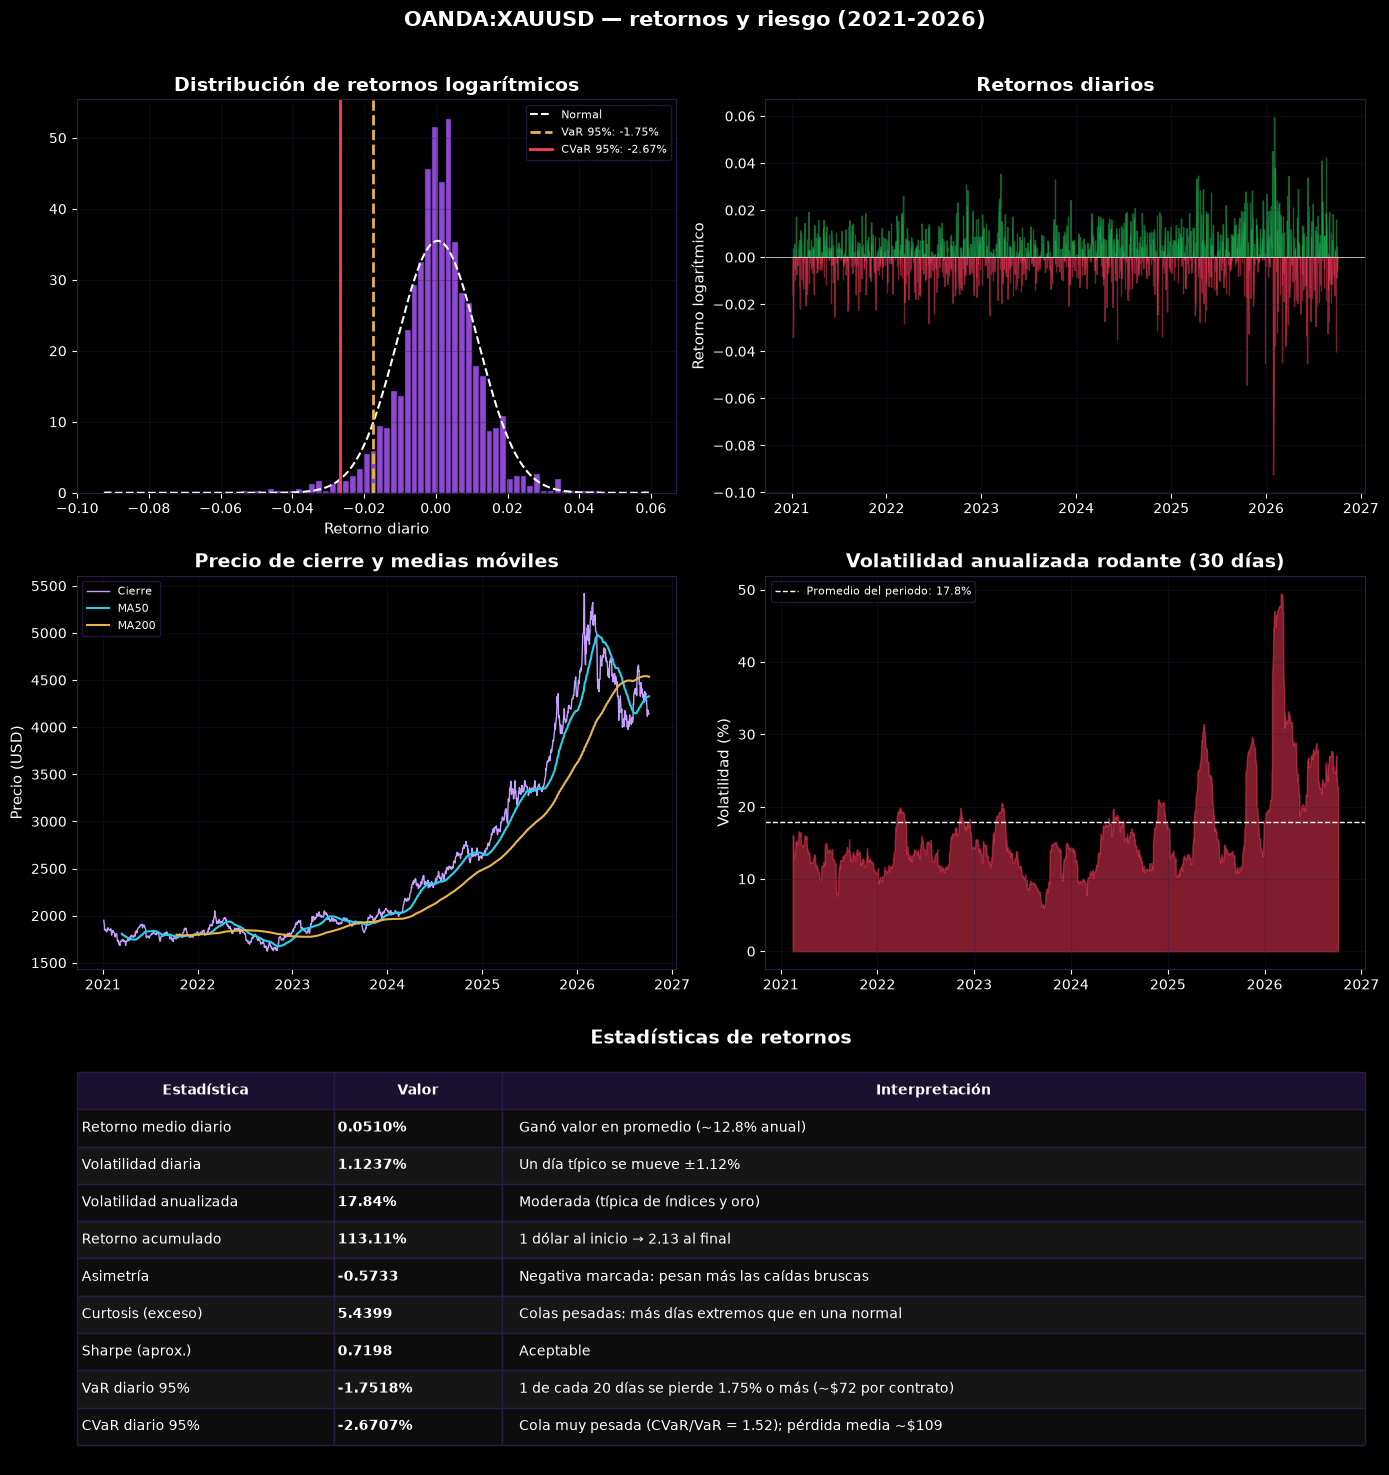

In [4]:
s = estadisticas.calcular_stats(r)
multiplicador = datos.multiplicador(TICKER)
filas = estadisticas.tabla_resumen(s, df['Close'].iloc[-1], multiplicador)

s_sin = estadisticas.calcular_stats(r[~df['outlier_ret']])
print(f"Volatilidad anual con outliers: {s['vol_a']:.2%} | sin outliers: {s_sin['vol_a']:.2%}")

g.dashboard(df, r, s, filas, TICKER, guardar='01_dashboard')

### Forma de la distribución

Si los retornos tienen colas más pesadas que la normal, un VaR calculado con la normal se queda corto. Se compara contra una t de Student ajustada por máxima verosimilitud.

Jarque-Bera:  1,897.23 (p = 0)
Shapiro-Wilk: 0.9498 (p = 4.16e-22)
Se rechaza normalidad: con la normal se subestima el riesgo de cola.

t de Student: 3.67 grados de libertad (colas muy pesadas)
AIC normal: -9,113.8 | AIC t: -9,327.2 → mejor ajuste: t

Días a más de 3σ: 23 observados, 4.0 esperados con la normal, 22.6 con la t


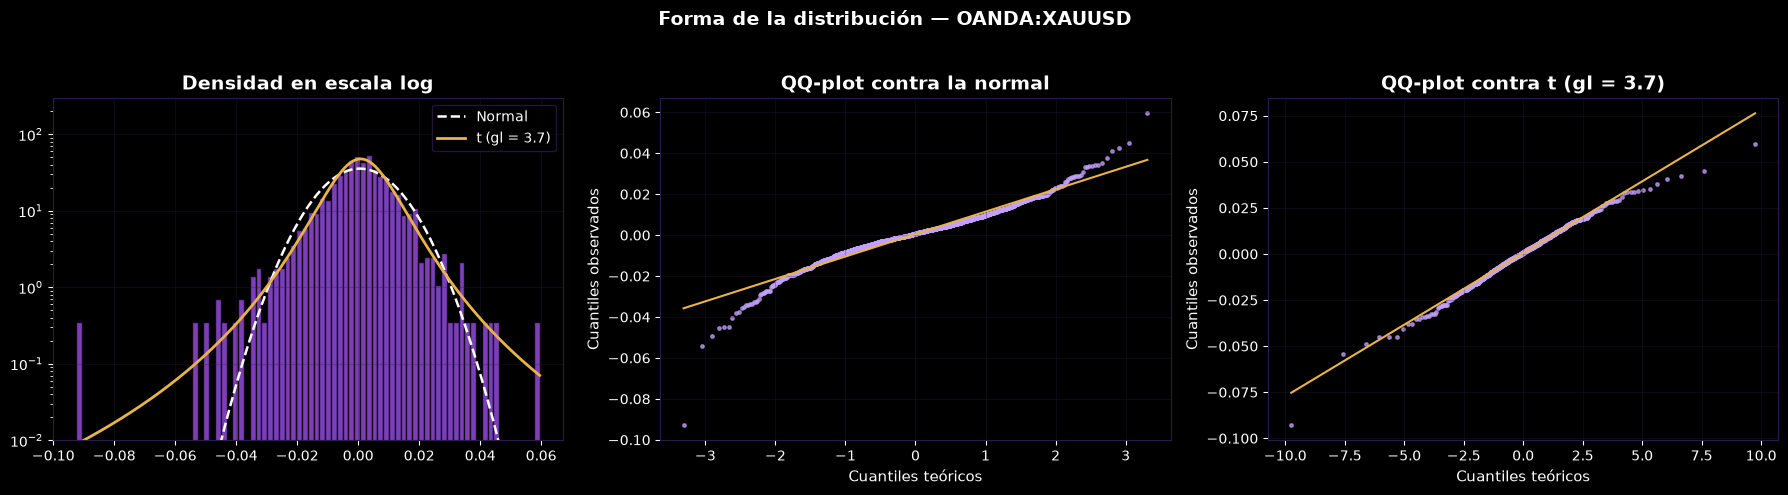

,Histórico,Normal,t de Student
Confianza,,,
95%,-1.7520,-1.7970,-1.6360
99%,-3.2780,-2.5620,-3.0080


In [5]:
ajuste = estadisticas.pruebas_normalidad(r)
estadisticas.reporte_normalidad(ajuste)
g.distribucion(r, ajuste, TICKER, guardar='02_distribucion')

# VaR diario en % según cada método
(ajuste['tabla_var'] * 100).round(3)

## 3. El sistema MGC / MNQ

Desde aquí se trabaja con los dos contratos en fechas comunes. Los retornos van en % porque GARCH converge mejor en esa escala.

In [6]:
precios, ohlc, retornos = datos.cargar_sistema(SISTEMA, PRINCIPAL, INICIO, FIN)
serie = precios[PRINCIPAL]
ret = retornos[PRINCIPAL]

print(f'{len(precios)} observaciones: {precios.index[0].date()} a {precios.index[-1].date()}')
datos.resumen_precios(precios, retornos)

4333 observaciones: 2010-01-01 a 2026-10-05


,Inicial,Final,Retorno (%),Vol. anual (%)
Ticker,,,,
OANDA:XAUUSD,"1,097.3800","4,140.4200",277.3000,16.4000
OANDA:USDJPY,93.0500,158.0100,69.8000,9.2000


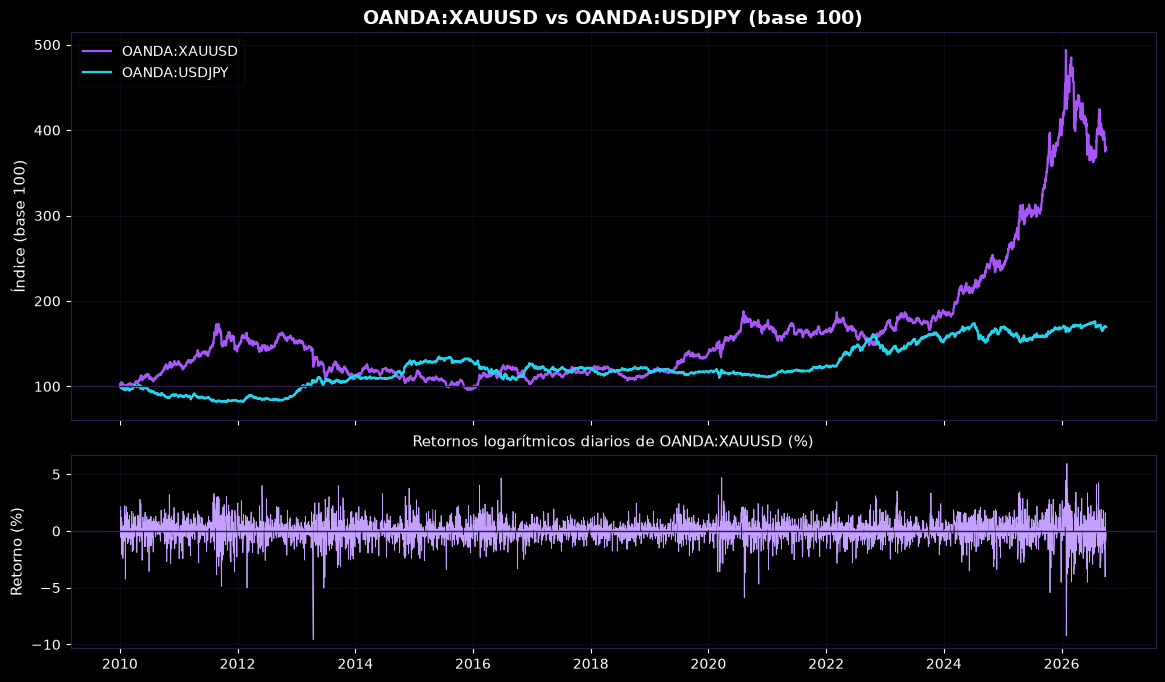

In [7]:
g.series(precios, ret, PRINCIPAL, guardar='03_series')

Los precios tienen tendencia; los retornos oscilan alrededor de cero, pero su amplitud no es constante. Esas rachas de días agitados (volatility clustering) son lo que modela GARCH más abajo.

### Estacionariedad

ADF y KPSS tienen hipótesis nulas opuestas, así que se usan juntas: una serie es estacionaria si ADF rechaza y KPSS no.

In [8]:
diagnostico.tabla_estacionariedad(serie, ret, PRINCIPAL)

/Users/juancamilo/Documents/CODE/WP QUANT/series-tiempo-futuros TRADINGVIEW/seriesfin/diagnostico.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_adf = adfuller(x, autolag='AIC')[1]
/Users/juancamilo/Documents/CODE/WP QUANT/series-tiempo-futuros TRADINGVIEW/seriesfin/diagnostico.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  p_adf = adfuller(x, autolag='AIC')

,ADF p,KPSS p,Veredicto
Serie,,,
OANDA:XAUUSD precio,0.9858,0.0100,No estacionaria
OANDA:XAUUSD Δ precio,0.0000,0.0580,Estacionaria
OANDA:XAUUSD retorno log,0.0000,0.1000,Estacionaria
OANDA:XAUUSD retorno²,0.0000,0.0140,Ambigua


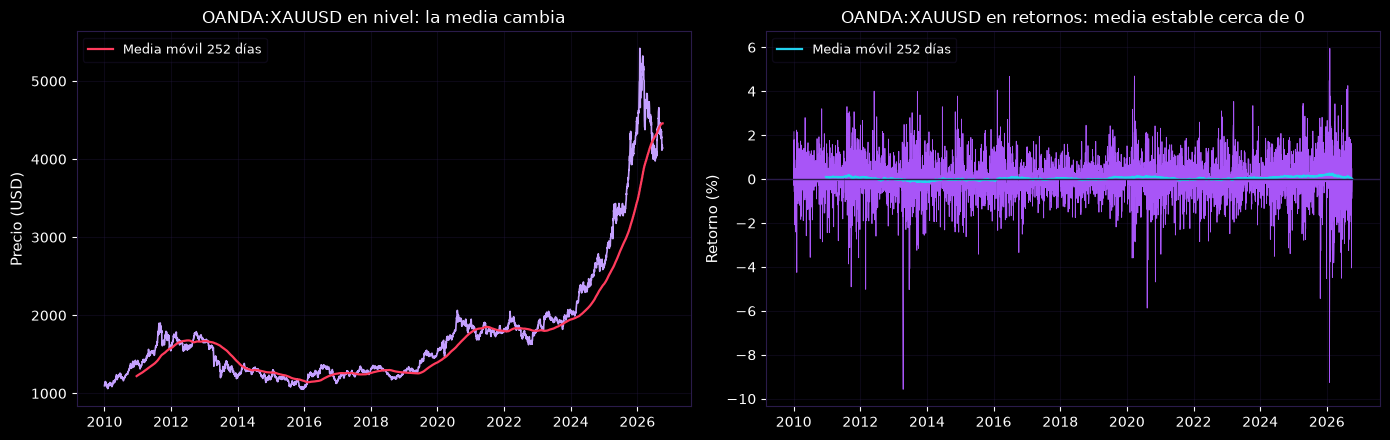

In [9]:
g.nivel_vs_retornos(serie, ret, PRINCIPAL)

El precio en nivel no es estacionario, por eso el ARIMA usa d = 1. Los retornos sí lo son, y sobre ellos trabajan GARCH y el VAR.

### Autocorrelación

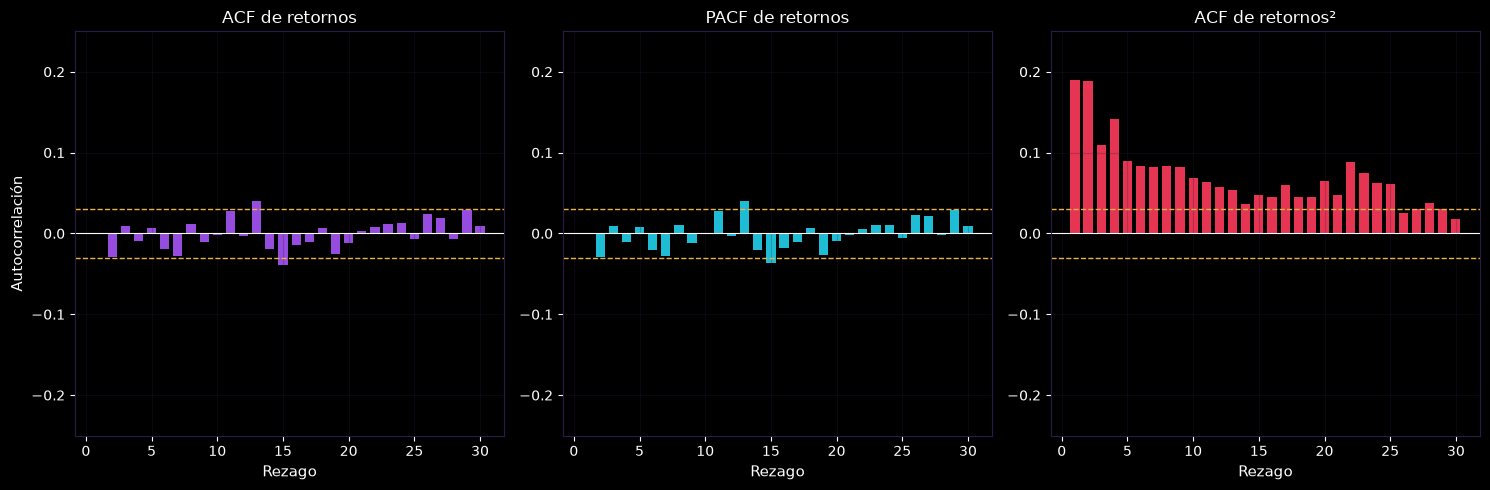

Rezagos significativos (de 30): retornos 2, retornos² 28


In [10]:
ac = diagnostico.autocorrelaciones(ret, nlags=30)
g.autocorrelaciones(ac, guardar='04_acf')

sig = diagnostico.rezagos_significativos(ac)
print(f"Rezagos significativos (de 30): retornos {sig['retornos']}, retornos² {sig['retornos²']}")

La ACF de los retornos es casi plana: la dirección del día siguiente es difícil de anticipar. La de los retornos al cuadrado sí persiste, o sea que la *magnitud* de los movimientos tiene memoria.

## 4. ARIMA

El orden (p, 1, q) se elige por AIC en una rejilla de 0 a 3, usando solo el periodo de entrenamiento.

In [11]:
train, test = arima.dividir(serie, CORTE)
print(f'Train: {len(train)} obs. ({train.index[0].date()} a {train.index[-1].date()})')
print(f'Test:  {len(test)} obs. ({test.index[0].date()} a {test.index[-1].date()})')

tabla_aic, orden = arima.seleccionar_orden(train)
print(f'\nOrden elegido: ARIMA{orden}')
tabla_aic.head()

Train: 4318 obs. (2010-01-01 a 2026-09-14)
Test:  15 obs. (2026-09-15 a 2026-10-05)

Orden elegido: ARIMA(3, 1, 3)


,p,d,q,AIC,BIC
0,3,1,3,"40,264.1500","40,308.7400"
1,2,1,3,"40,272.7200","40,310.9500"
2,0,1,2,"40,295.6000","40,314.7100"
3,2,1,0,"40,296.3300","40,315.4400"
4,1,1,2,"40,296.6600","40,322.1500"


In [12]:
modelo_arima = arima.ajustar(train, orden)
resid = arima.residuos(modelo_arima, train, orden)

display(arima.coeficientes(modelo_arima))

# Ljung-Box, H0: los residuos son ruido blanco
arima.ljung_box(resid, orden).round(4)

,coef,p-valor
ar.L1,-0.6842,0.0000
ar.L2,-0.6814,0.0000
ar.L3,-0.9732,0.0000
ma.L1,0.6741,0.0000
ma.L2,0.6521,0.0000
ma.L3,0.9564,0.0000
sigma2,646.2023,0.0000


,lb_stat,lb_pvalue
10,70.9886,0.0000
20,179.9389,0.0000


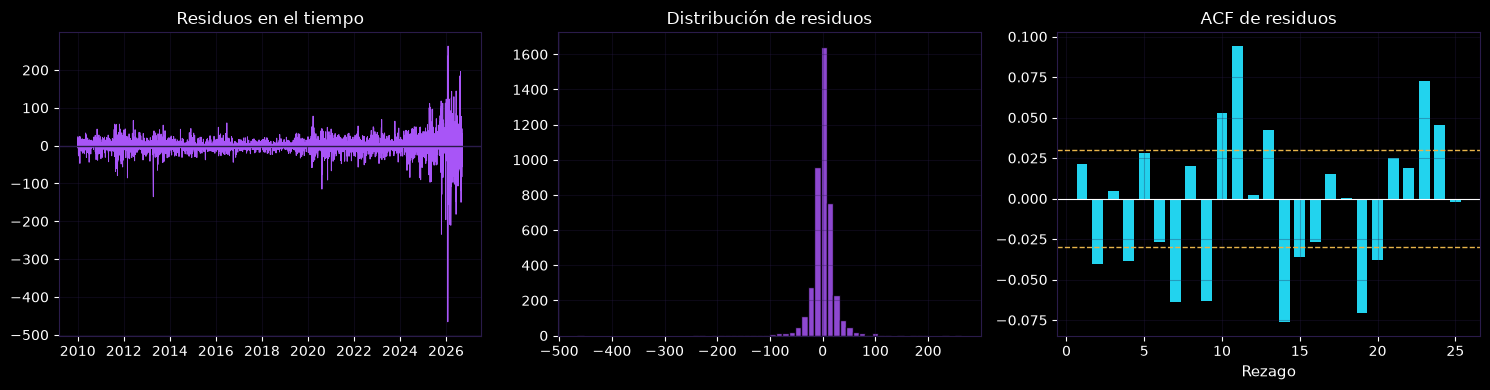

In [13]:
g.residuos_arima(resid)

### Pronóstico

Pronóstico dinámico sobre todo el test y `H_FUT` días hábiles más, con bandas al 80, 95 y 99%.

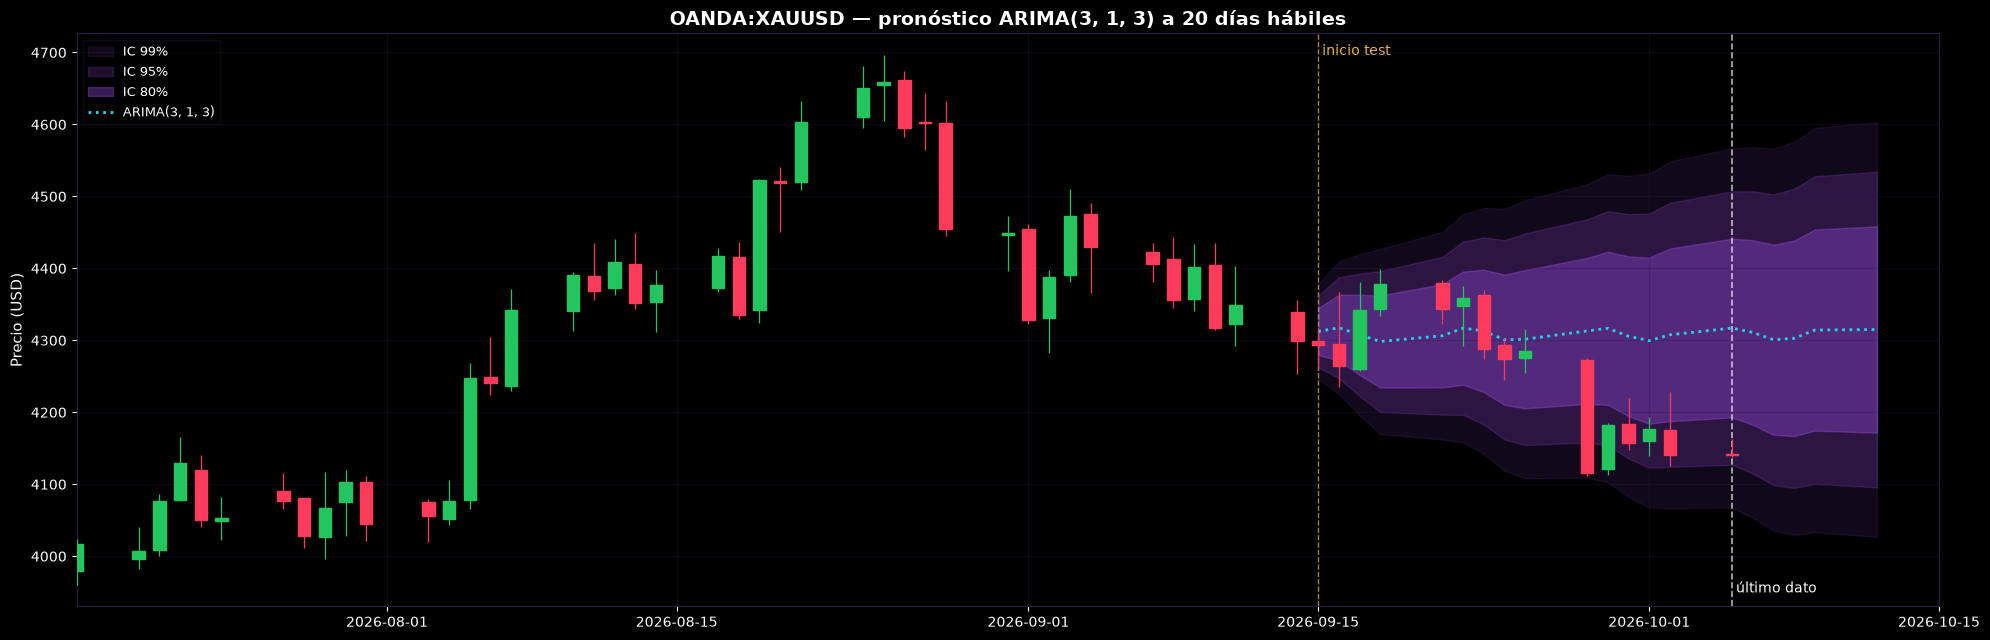

Ancho del IC 95%: $100 el primer día y $439 el día 20


In [14]:
pron = arima.pronosticar(modelo_arima, test, H_FUT)
g.pronostico_arima(ohlc, pron, CORTE, orden, PRINCIPAL, guardar='05_pronostico_arima')

ancho = pron['sup_95'] - pron['inf_95']
print(f'Ancho del IC 95%: ${ancho.iloc[0]:,.0f} el primer día y ${ancho.iloc[-1]:,.0f} el día {len(pron)}')

Un ARIMA(p,1,q) sin drift converge rápido al último precio conocido. A horizontes largos lo útil es el intervalo, no la línea central.

### Evaluación fuera de muestra

Cada pronóstico se compara con el benchmark que le corresponde: el de 1 paso contra el precio de ayer (paseo aleatorio) y el multi-paso contra el último precio del entrenamiento. La U de Theil es el cociente de RMSE: menor que 1 significa que el modelo le gana al ingenuo.

In [15]:
pred_1paso = evaluacion.pronostico_un_paso(modelo_arima, serie, train, test)
tabla_eval = evaluacion.evaluar(test, train, serie, pred_1paso, pron['media'], orden)
tabla_eval

,RMSE,MAE,MAPE (%),R²,U de Theil
Modelo,,,,,
"ARIMA(3, 1, 3) a 1 paso",61.3400,43.5235,1.0301,0.4938,1.0527
Ingenuo: precio de ayer,58.2692,40.9993,0.9706,0.5432,1.0000
"ARIMA(3, 1, 3) a 15 pasos",106.1753,85.4582,2.0381,-0.5167,1.0639
Ingenuo: último precio del train,99.8024,80.1733,1.9108,-0.3401,1.0000


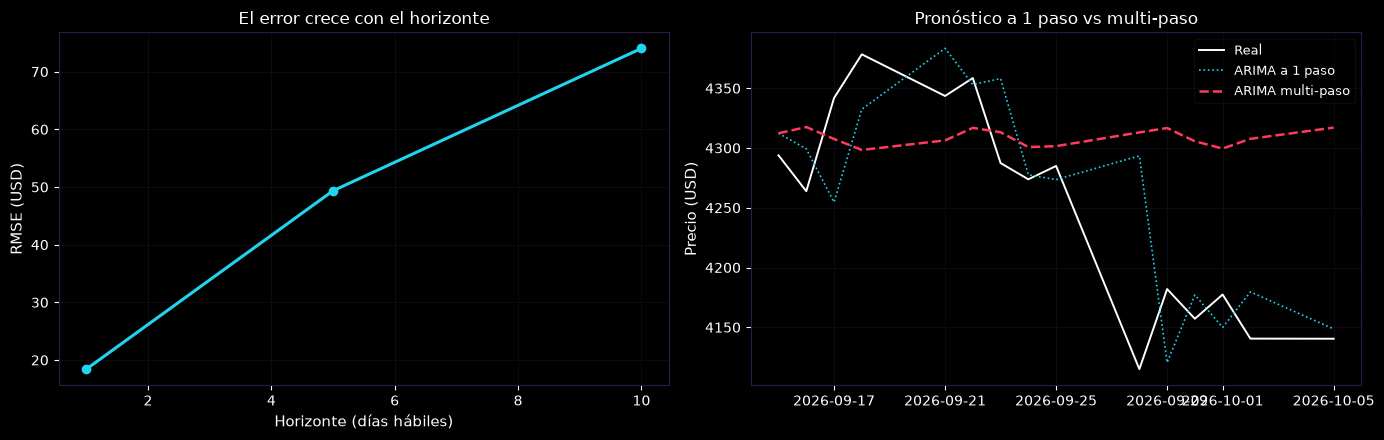

,RMSE,MAE,U de Theil
Horizonte,,,
1,18.4205,18.4205,3.2690
5,49.3491,44.7071,1.0402
10,74.0367,53.2646,1.0490


In [16]:
tabla_h = evaluacion.error_por_horizonte(pron['media'], test, train)
g.error_horizonte(tabla_h, test, pred_1paso, pron['media'], guardar='06_error_horizonte')
tabla_h

El R² del pronóstico a 1 paso sale altísimo porque el precio de hoy se parece mucho al de ayer, no porque el modelo sepa algo. La U de Theil lo deja claro: si queda cerca de 1, el ARIMA no aporta nada frente al paseo aleatorio, que es lo esperable en un activo tan líquido.

## 5. Volatilidad

Primero se confirma que hay efecto ARCH; si lo hay, tiene sentido modelar la varianza condicional.

ARCH-LM: 329.31 (p = 9.7e-65)


/opt/anaconda3/envs/juan/lib/python3.14/site-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


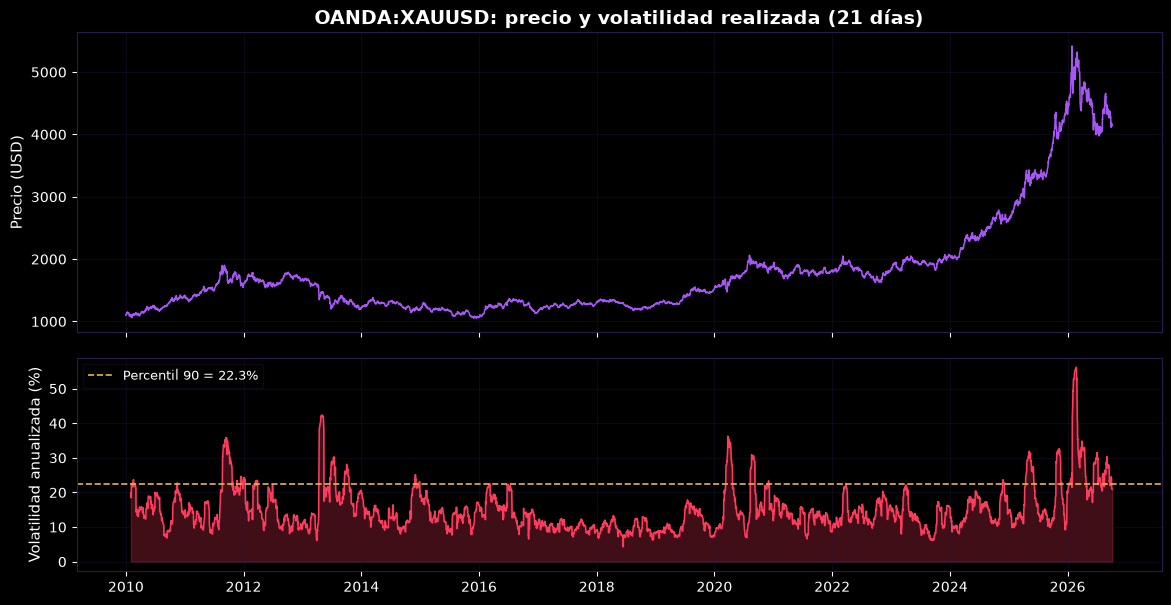

Días con volatilidad sobre el percentil 90: 432


In [17]:
lm, p_lm = diagnostico.prueba_arch(ret)
print(f'ARCH-LM: {lm:.2f} (p = {p_lm:.2g})')

dias_altos = g.clustering(serie, ret, PRINCIPAL, guardar='07_clustering')
print(f'Días con volatilidad sobre el percentil 90: {dias_altos}')

### GARCH(1,1) con innovaciones t

Se usa la t de Student por lo visto en la sección 2: las colas son más pesadas que las de una normal.

,valor
mu,0.0412
omega,0.0127
alpha[1],0.0483
beta[1],0.9412
nu,4.7985


Persistencia α + β: 0.9895 (vida media de un shock: 65.7 días)
Volatilidad actual: 23.1% | largo plazo: 17.5%


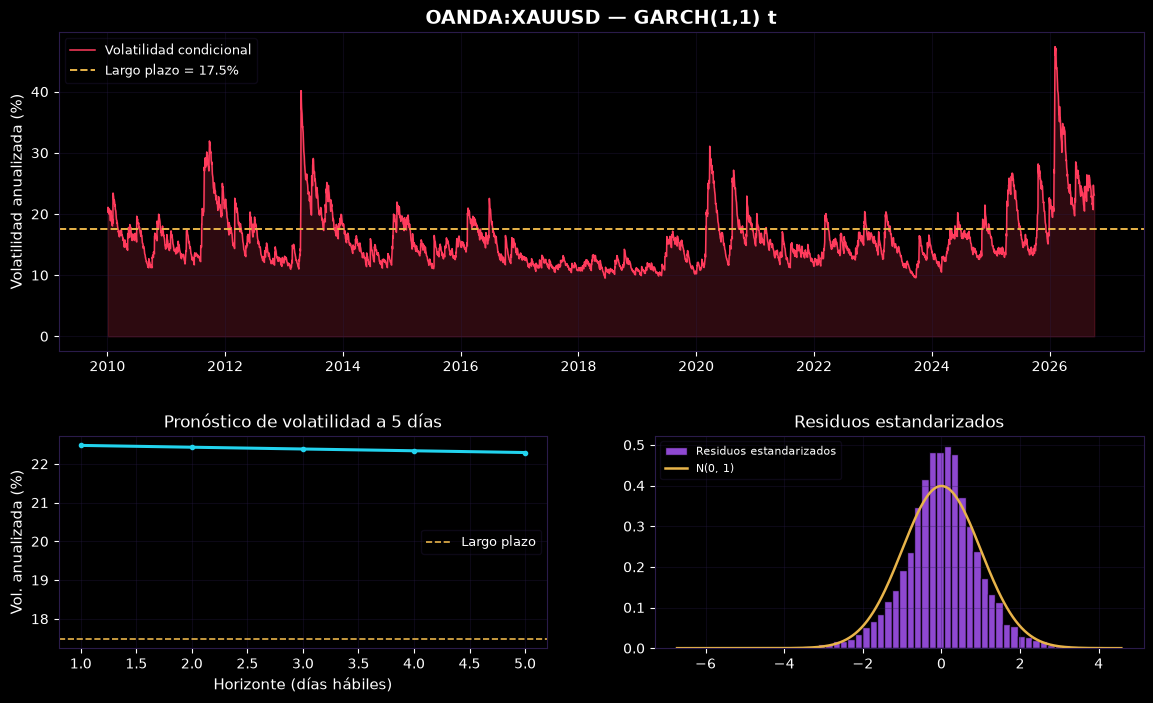

In [18]:
ret_garch = ret.loc[ret.index < pd.Timestamp(CORTE)] if GARCH_SOLO_TRAIN else ret

config_base = volatilidad.configuracion('Garch', p=1, o=0, q=1, dist='t')
garch_base = volatilidad.ajustar(ret_garch, config_base)
v_base = volatilidad.resumir(garch_base, config_base, HORIZONTE_VOL)

display(garch_base.params.round(5).to_frame('valor'))
print(f"Persistencia α + β: {v_base['persistencia']:.4f} "
      f"(vida media de un shock: {v_base['vida_media']:.1f} días)")
print(f"Volatilidad actual: {v_base['vol_cond'].iloc[-1]:.1f}% | largo plazo: {v_base['vol_lp']:.1f}%")

g.volatilidad(v_base, garch_base, PRINCIPAL)

### Búsqueda del modelo de volatilidad

GARCH, GJR-GARCH (asimetría con `o = 1`) y EGARCH, con órdenes 1 y 2 e innovaciones t o t asimétrica. Se descartan los ajustes que no convergen y se ordena por AIC.

In [19]:
tabla_vol, garch, config = volatilidad.buscar_modelo(ret_garch)
v = volatilidad.resumir(garch, config, HORIZONTE_VOL)

print(f"Mejor modelo por AIC: {config['nombre']}\n")
for linea in volatilidad.interpretar(v):
    print('-', linea)

tabla_vol.head(8)

Mejor modelo por AIC: EGARCH(2,1,1) t asimétrica

- Reacción a shocks (α = 0.1305): en EGARCH α actúa sobre log(σ²), no se compara directamente con el de un GARCH.
- Memoria (β = 0.9846): la volatilidad tarda en calmarse.
- Persistencia = 0.9846; un shock tarda 44.8 días hábiles en perder la mitad de su efecto.
- Asimetría (γ = 0.0286): las subidas suben la volatilidad más que las caídas; es común en el oro por su papel de refugio.
- Grados de libertad = 4.79: colas muy pesadas.


,AIC,BIC,Log-verosimilitud
Modelo,,,
"EGARCH(2,1,1) t asimétrica","11,506.8200","11,557.8100","-5,745.4100"
"EGARCH(2,1,2) t asimétrica","11,508.8200","11,566.1800","-5,745.4100"
"GJR-GARCH(1,1,1) t asimétrica","11,510.4900","11,555.1100","-5,748.2500"
"GJR-GARCH(2,1,1) t asimétrica","11,511.4500","11,562.4400","-5,747.7300"
"GJR-GARCH(1,1,2) t asimétrica","11,512.4900","11,563.4800","-5,748.2500"
"GJR-GARCH(2,1,2) t asimétrica","11,513.4500","11,570.8200","-5,747.7300"
"EGARCH(1,1,1) t asimétrica","11,513.5500","11,558.1700","-5,749.7800"
"EGARCH(2,1,1) t","11,513.8700","11,558.4800","-5,749.9300"


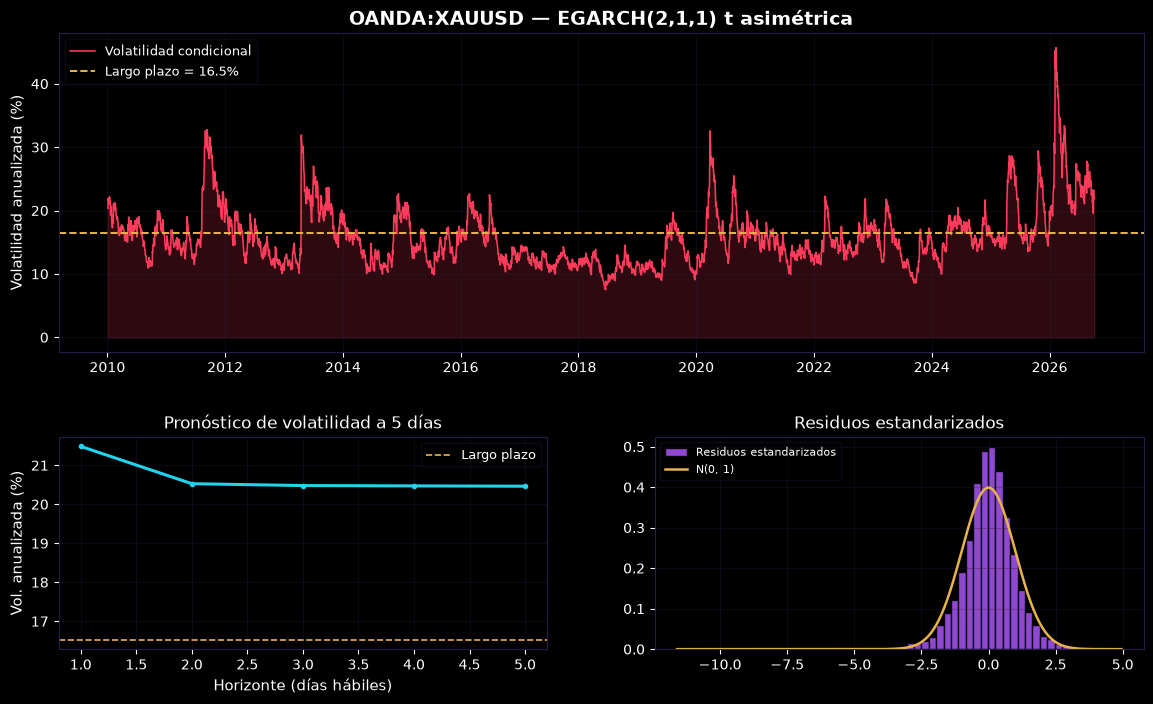

Volatilidad actual:          21.85%
Pronóstico para mañana:      21.48%
Pronóstico a 5 días:        20.46%
Nivel de largo plazo:        16.53%


In [20]:
g.volatilidad(v, garch, PRINCIPAL, guardar='08_volatilidad')

print(f"Volatilidad actual:          {v['vol_cond'].iloc[-1]:.2f}%")
print(f"Pronóstico para mañana:      {v['vol_pron'][0]:.2f}%")
print(f"Pronóstico a {HORIZONTE_VOL} días:        {v['vol_pron'][-1]:.2f}%")
print(f"Nivel de largo plazo:        {v['vol_lp']:.2f}%")

GARCH no dice hacia dónde va el precio, dice qué tan movido viene el camino. Eso es lo que sirve para dimensionar posiciones y ajustar stops.

## 6. VAR entre oro y Nasdaq

In [21]:
tabla_lags, rezagos = sistema.seleccionar_rezagos(retornos)
modelo_var = sistema.ajustar(retornos, rezagos)
print(f'VAR({rezagos}) | AIC {modelo_var.aic:.4f} | BIC {modelo_var.bic:.4f}')
tabla_lags

VAR(1) | AIC -1.1549 | BIC -1.1461


,Rezagos
AIC,0
BIC,0
HQIC,0
FPE,0


### Causalidad de Granger

p-valores. H0: los rezagos de la **columna** no ayudan a predecir la **fila** más allá de lo que la fila ya explica de sí misma.

In [22]:
sistema.matriz_granger(modelo_var)

,OANDA:XAUUSD,OANDA:USDJPY
OANDA:XAUUSD,NaN,0.2179
OANDA:USDJPY,0.4754,NaN


### Impulso-respuesta y pronóstico

La IRF ortogonalizada depende del orden de las variables (Cholesky). Por eso se dibuja también con el orden invertido (línea punteada): si las curvas casi coinciden, el resultado no depende del orden. Eso pasa cuando la correlación contemporánea de los residuos es baja.

Correlación contemporánea de los residuos: -0.336


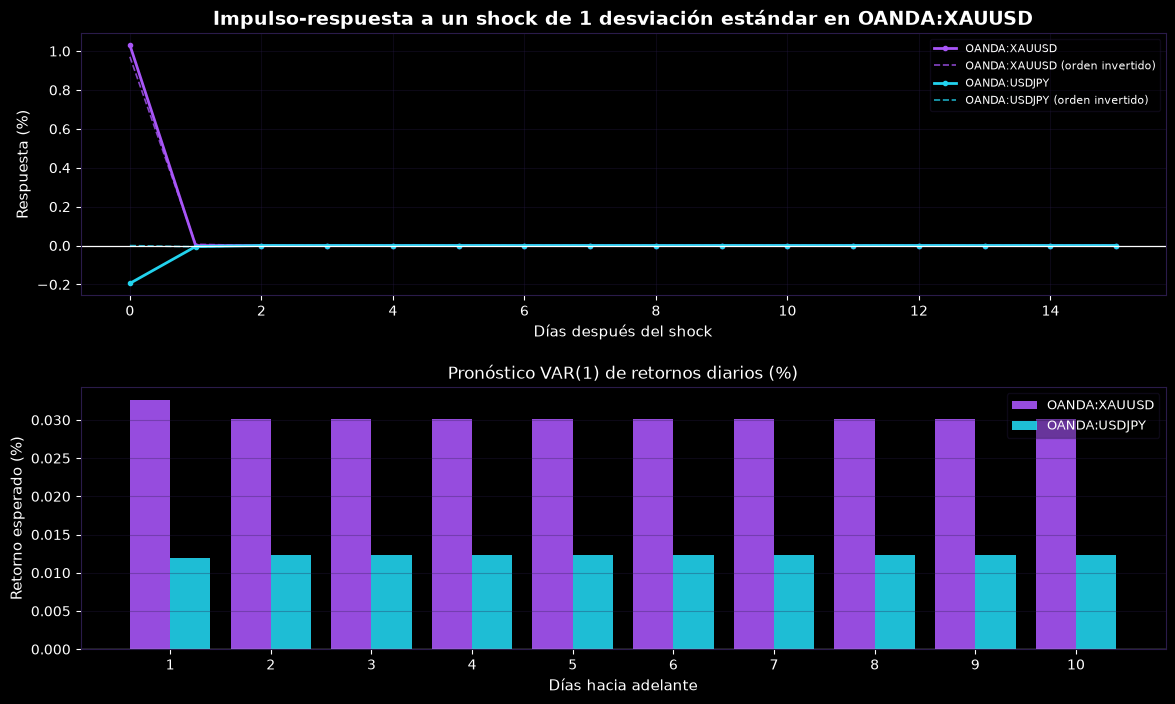

,OANDA:XAUUSD,OANDA:USDJPY
Día,,
1,0.0327,0.0119
2,0.0302,0.0124
3,0.0302,0.0124
4,0.0302,0.0124
5,0.0302,0.0124
6,0.0302,0.0124
7,0.0302,0.0124
8,0.0302,0.0124
9,0.0302,0.0124


In [23]:
irf = sistema.impulso_respuesta(retornos, rezagos, PRINCIPAL)
pron_var = sistema.pronosticar(modelo_var, retornos)

print(f'Correlación contemporánea de los residuos: {sistema.correlacion_residuos(modelo_var):.3f}')
g.var_sistema(irf, pron_var, PRINCIPAL, modelo_var.k_ar, guardar='09_var')
pron_var.round(4)

Los retornos pronosticados son diminutos, y está bien que así sea: el retorno esperado diario de un activo líquido es casi cero. Lo interesante del VAR es la estructura de respuestas cruzadas, no el nivel del pronóstico.

## 7. Resumen

In [24]:
pd.Series({
    f'Volatilidad anual {TICKER}': f"{s['vol_a']:.1%}",
    f'VaR 95% diario {TICKER}': f"{s['var']:.2%}",
    f'Grados de libertad t {TICKER}': f"{ajuste['t'][0]:.1f}",
    f'Orden ARIMA {PRINCIPAL}': str(orden),
    'U de Theil a 1 paso': f"{tabla_eval['U de Theil'].iloc[0]:.3f}",
    'Modelo de volatilidad': config['nombre'],
    'Volatilidad actual': f"{v['vol_cond'].iloc[-1]:.1f}%",
    f'Volatilidad a {HORIZONTE_VOL} días': f"{v['vol_pron'][-1]:.1f}%",
    'Vida media de un shock': f"{v['vida_media']:.1f} días",
    'Rezagos del VAR': str(rezagos),
}, name='Valor').to_frame()

,Valor
Volatilidad anual OANDA:XAUUSD,17.8%
VaR 95% diario OANDA:XAUUSD,-1.75%
Grados de libertad t OANDA:XAUUSD,3.7
Orden ARIMA OANDA:XAUUSD,"(3, 1, 3)"
U de Theil a 1 paso,1.053
Modelo de volatilidad,"EGARCH(2,1,1) t asimétrica"
Volatilidad actual,21.9%
Volatilidad a 5 días,20.5%
Vida media de un shock,44.8 días
Rezagos del VAR,1


**Conclusiones**

- Los retornos no son normales: colas pesadas y más días extremos de los que predice la normal. Para medir riesgo conviene el VaR histórico o con t.
- El precio no es predecible con ARIMA: frente al paseo aleatorio la U de Theil queda alrededor de 1.
- La volatilidad sí es predecible: hay efecto ARCH claro y los shocks tardan días en disiparse. Es la parte del análisis que sirve en la práctica (tamaño de posición, stops, VaR condicional).
- El VAR sirve más para ver cómo se transmite un shock entre oro y Nasdaq que para pronosticar retornos.

**Limitaciones**

- Futuros continuos de TradingView sin ajuste por roll.
- No hay costos de transacción ni re-estimación de los modelos en el test (walk-forward).
- Es un ejercicio de análisis, no una recomendación de inversión.